In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid')

PROCESSED_PATH = '../data/processed/'
OUTPUT_PATH    = '../outputs/'
import os; os.makedirs(OUTPUT_PATH, exist_ok=True)

df_acn = pd.read_csv(PROCESSED_PATH + 'acn_caltech_processed.csv', parse_dates=['connectionTime','disconnectTime'])
df_ev  = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv',    parse_dates=['timestamp'])

print("ACN shape :", df_acn.shape)
print("EV shape  :", df_ev.shape)

ACN shape : (14848, 28)
EV shape  : (2134080, 15)


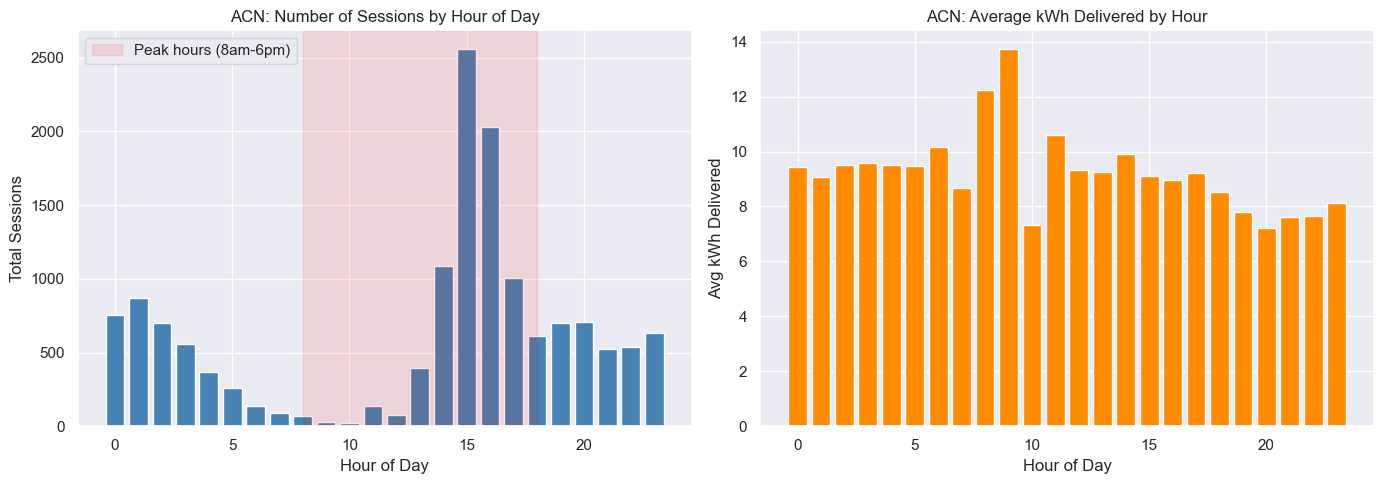

Insight: Peak charging hours and average energy consumption pattern


In [ ]:
hourly_acn = df_acn.groupby('hour_of_day').agg(
    avg_sessions  = ('kWhDelivered', 'count'),
    avg_kwh       = ('kWhDelivered', 'mean'),
    avg_revenue   = ('revenue_session', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_acn['hour_of_day'], hourly_acn['avg_sessions'], color='steelblue')
axes[0].set_title('ACN: Number of Sessions by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Sessions')
axes[0].axvspan(8, 18, alpha=0.1, color='red', label='Peak hours (8am-6pm)')
axes[0].legend()

axes[1].bar(hourly_acn['hour_of_day'], hourly_acn['avg_kwh'], color='darkorange')
axes[1].set_title('ACN: Average kWh Delivered by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg kWh Delivered')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'acn_hourly_demand.png', bbox_inches='tight')
plt.show()
print("Peak charging hours and average energy consumption pattern")

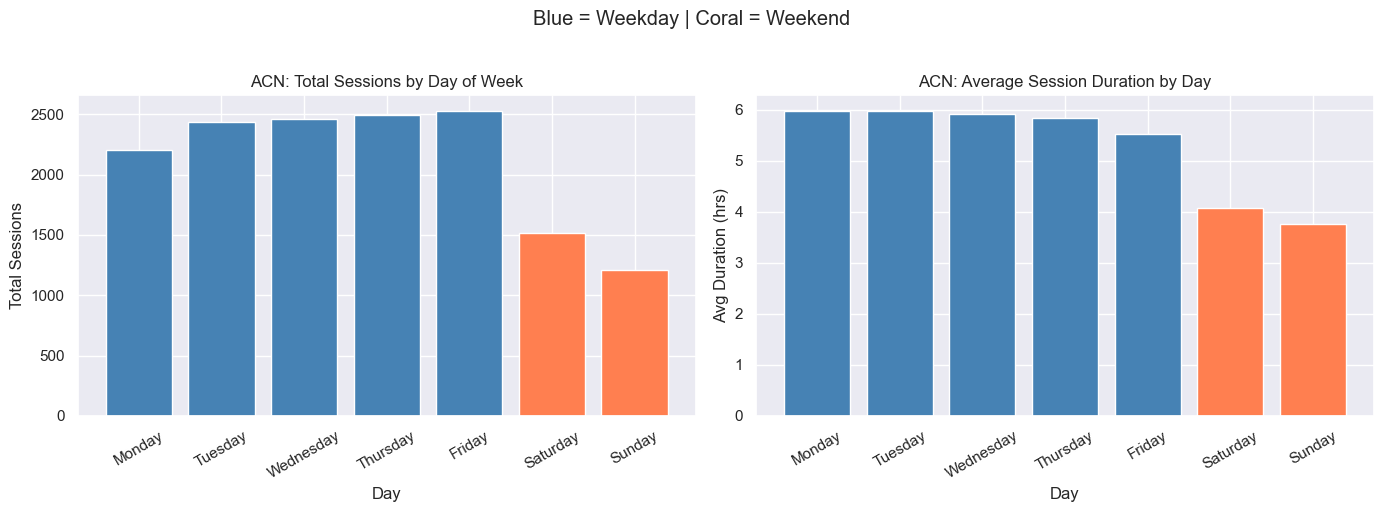

In [ ]:
df_acn['day_name'] = df_acn['connectionTime'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily = df_acn.groupby('day_name').agg(
    sessions      = ('kWhDelivered', 'count'),
    avg_kwh       = ('kWhDelivered', 'mean'),
    avg_duration  = ('session_duration_hrs', 'mean')
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue']*5 + ['coral']*2
axes[0].bar(daily['day_name'], daily['sessions'], color=colors)
axes[0].set_title('ACN: Total Sessions by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Sessions')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(daily['day_name'], daily['avg_duration'], color=colors)
axes[1].set_title('ACN: Average Session Duration by Day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Duration (hrs)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Blue = Weekday | Orange = Weekend', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'acn_weekday_weekend.png', bbox_inches='tight')
plt.show()

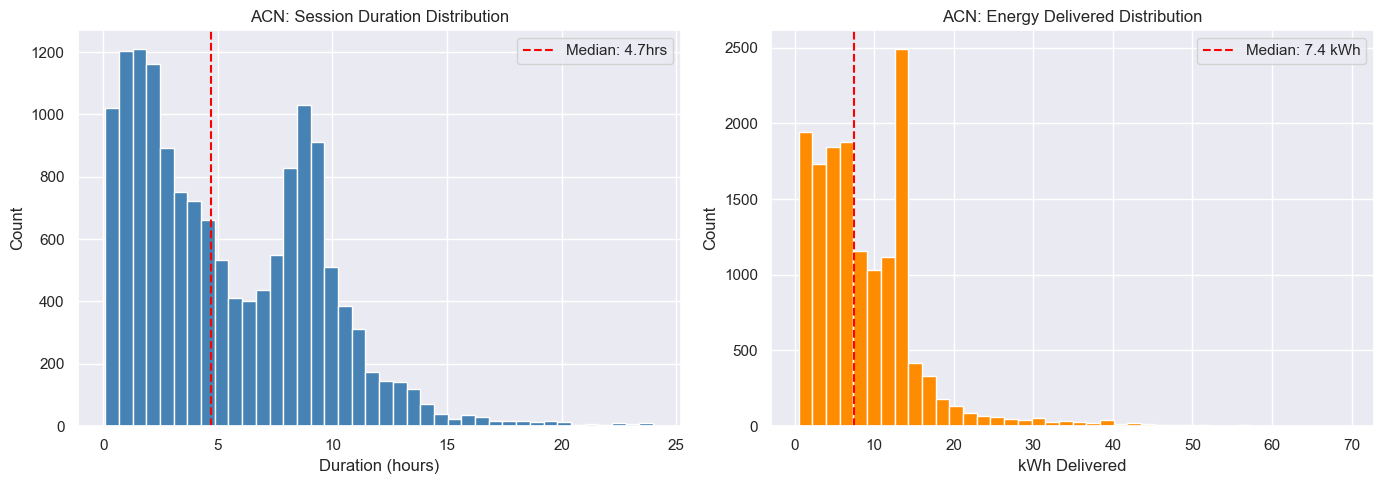

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_acn['session_duration_hrs'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('ACN: Session Duration Distribution')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Count')
axes[0].axvline(df_acn['session_duration_hrs'].median(), color='red', linestyle='--', 
                label=f"Median: {df_acn['session_duration_hrs'].median():.1f}hrs")
axes[0].legend()

axes[1].hist(df_acn['kWhDelivered'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('ACN: Energy Delivered Distribution')
axes[1].set_xlabel('kWh Delivered')
axes[1].set_ylabel('Count')
axes[1].axvline(df_acn['kWhDelivered'].median(), color='red', linestyle='--',
                label=f"Median: {df_acn['kWhDelivered'].median():.1f} kWh")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'acn_distributions.png', bbox_inches='tight')
plt.show()

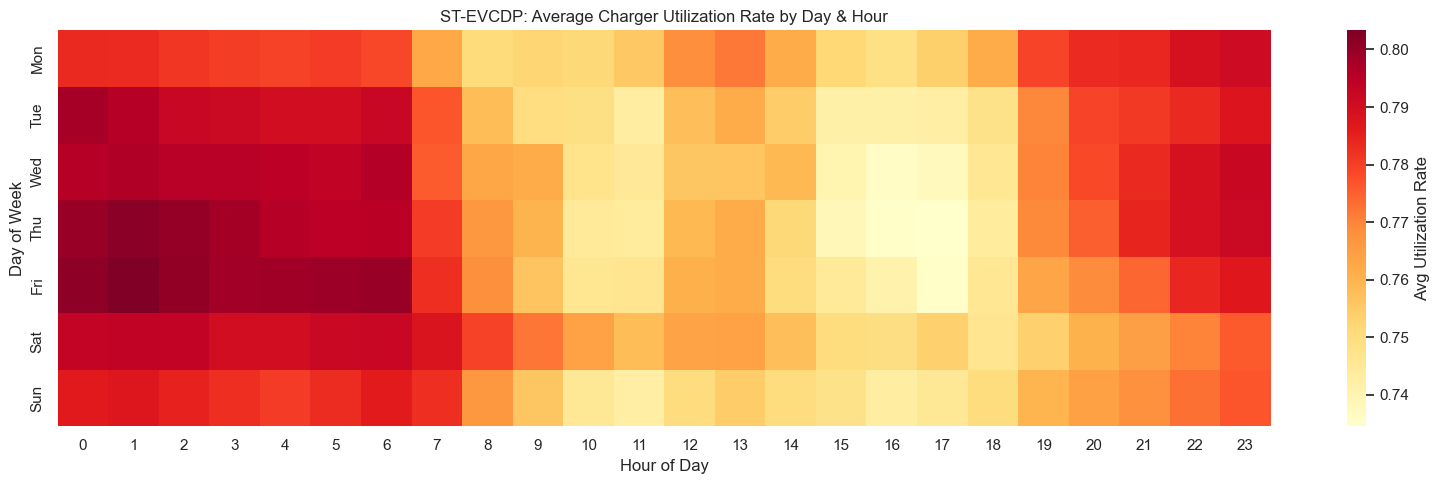

Insight: Which day/hour combos have peak utilization — directly drives surge pricing logic


In [ ]:
heatmap_data = df_ev.groupby(['day_of_week','hour_of_day'])['utilization_rate'].mean().unstack()
heatmap_data.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, 
            cbar_kws={'label': 'Avg Utilization Rate'})
plt.title('ST-EVCDP: Average Charger Utilization Rate by Day & Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_utilization_heatmap.png', bbox_inches='tight')
plt.show()
print("Which day/hour combos have peak utilization : directly drives surge pricing logic")

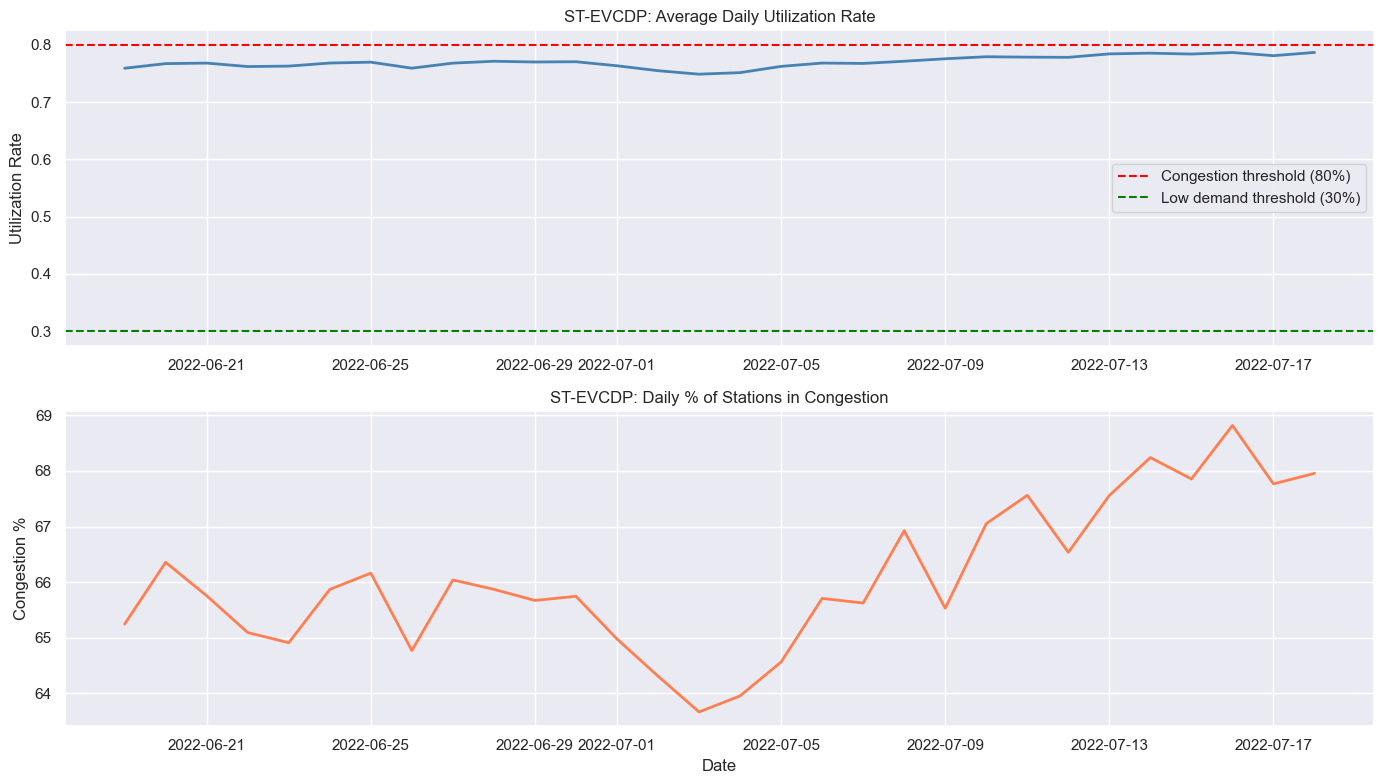

In [6]:
daily_ev = df_ev.groupby('date').agg(
    avg_utilization = ('utilization_rate', 'mean'),
    avg_volume      = ('volume', 'mean'),
    congestion_pct  = ('congestion_flag', 'mean')
).reset_index()
daily_ev['date'] = pd.to_datetime(daily_ev['date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_ev['date'], daily_ev['avg_utilization'], color='steelblue', linewidth=2)
axes[0].set_title('ST-EVCDP: Average Daily Utilization Rate')
axes[0].set_ylabel('Utilization Rate')
axes[0].axhline(0.8, color='red', linestyle='--', label='Congestion threshold (80%)')
axes[0].axhline(0.3, color='green', linestyle='--', label='Low demand threshold (30%)')
axes[0].legend()

axes[1].plot(daily_ev['date'], daily_ev['congestion_pct']*100, color='coral', linewidth=2)
axes[1].set_title('ST-EVCDP: Daily % of Stations in Congestion')
axes[1].set_ylabel('Congestion %')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_demand_over_time.png', bbox_inches='tight')
plt.show()

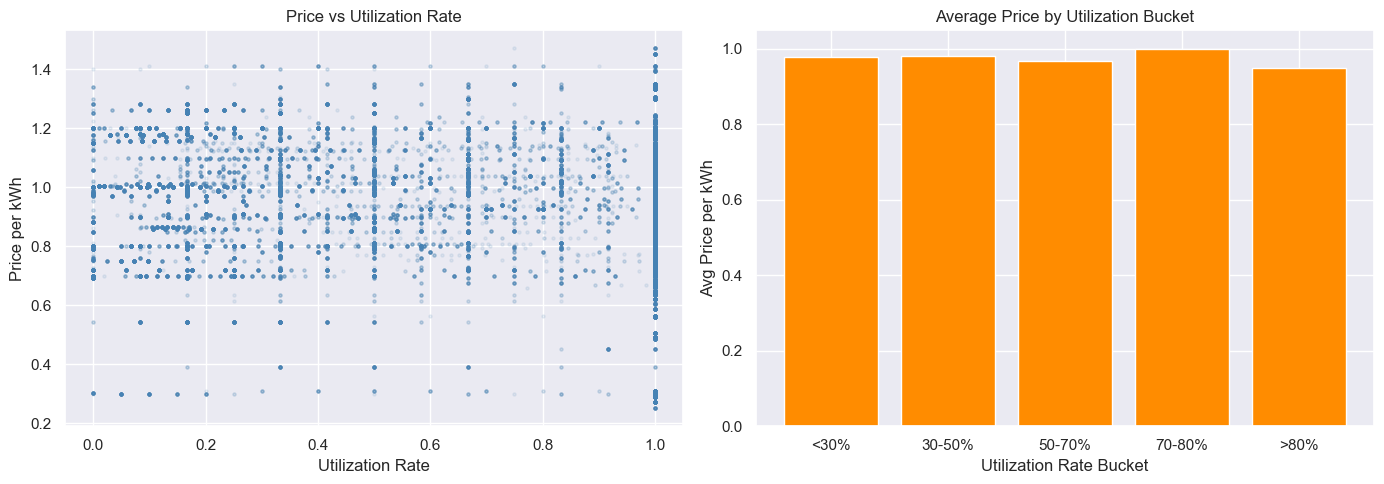

Insight: This shows whether current pricing already correlates with demand — key for tariff design


In [ ]:
sample = df_ev.sample(50000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['utilization_rate'], sample['price_per_kwh'], 
                alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Price vs Utilization Rate')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Price per kWh')


df_ev['util_bucket'] = pd.cut(df_ev['utilization_rate'], 
                               bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],
                               labels=['<30%','30-50%','50-70%','70-80%','>80%'])
price_by_util = df_ev.groupby('util_bucket')['price_per_kwh'].mean()

axes[1].bar(price_by_util.index, price_by_util.values, color='darkorange')
axes[1].set_title('Average Price by Utilization Bucket')
axes[1].set_xlabel('Utilization Rate Bucket')
axes[1].set_ylabel('Avg Price per kWh')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_price_vs_utilization.png', bbox_inches='tight')
plt.show()
print("This shows whether current pricing already correlates with demand, key for tariff design")

In [ ]:
acn_summary = pd.DataFrame({
    'metric': ['Total Sessions', 'Avg kWh/Session', 'Avg Duration (hrs)', 
               'Avg Revenue/Session (Rs)', 'Peak Hour', 'Median kWh'],
    'value': [
        len(df_acn),
        round(df_acn['kWhDelivered'].mean(), 2),
        round(df_acn['session_duration_hrs'].mean(), 2),
        round(df_acn['revenue_session'].mean(), 2),
        df_acn.groupby('hour_of_day')['kWhDelivered'].count().idxmax(),
        round(df_acn['kWhDelivered'].median(), 2)
    ]
})


ev_summary = pd.DataFrame({
    'metric': ['Total Records', 'Avg Utilization Rate', 'Congestion % of Time',
               'Low Demand % of Time', 'Avg Price/kWh', 'Unique Stations'],
    'value': [
        len(df_ev),
        round(df_ev['utilization_rate'].mean(), 3),
        round(df_ev['congestion_flag'].mean() * 100, 1),
        round(df_ev['low_demand_flag'].mean() * 100, 1),
        round(df_ev['price_per_kwh'].mean(), 3),
        df_ev['station_id'].nunique()
    ]
})

acn_summary.to_csv(OUTPUT_PATH + 'acn_eda_summary.csv', index=False)
ev_summary.to_csv(OUTPUT_PATH + 'evcdp_eda_summary.csv', index=False)

print("ACN Summary:")
print(acn_summary.to_string(index=False))
print("\nST-EVCDP Summary:")
print(ev_summary.to_string(index=False))

=== ACN Summary ===
                  metric    value
          Total Sessions 14848.00
         Avg kWh/Session     8.94
      Avg Duration (hrs)     5.50
Avg Revenue/Session (Rs)   134.14
               Peak Hour    15.00
              Median kWh     7.42

=== ST-EVCDP Summary ===
              metric       value
       Total Records 2134080.000
Avg Utilization Rate       0.770
Congestion % of Time      66.100
Low Demand % of Time      16.200
       Avg Price/kWh       0.959
     Unique Stations     247.000

Notebook 2 done! Ready for ML agents.
